## E . Etapa 2 — Ingesta
El proyecto deberá poseer un script reproducible:

python src/ingestion/ingest.py

que obtenga o prepare el dataset raw.

No será aceptable que el único mecanismo de entrada sea:

pd.read_csv("archivo_que_ya_tenia_en_mi_computadora.csv")

La ingesta deberá quedar documentada y reproducible.

In [1]:
# Llamado al archivo de código Python para realizar la ingesta de datos

import sys
from pathlib import Path

# Añadimos la raíz del proyecto al path de Python para poder importar 'src'
sys.path.append(str(Path.cwd().parent))

# Importamos la función desde el archivo Ingesta.py
from src.ingestion.Ingesta import ingest_data

# Ejecutamos la ingesta y obtenemos el DataFrame
df_raw = ingest_data()

2026-08-24 22:46:38,462 - INFO - Iniciando proceso de ingesta de datos...
2026-08-24 22:46:38,465 - INFO - Dataset ya encontrado localmente en 'data\raw\online_retail.csv'. Cargando desde disco...
2026-08-24 22:46:38,975 - INFO - Dataset cargado exitosamente: 541,909 filas y 8 columnas.


## F. Etapa 3 — Data Quality
Todos los grupos deberán desarrollar un diagnóstico de calidad.

Deberán investigar, cuando corresponda:

valores faltantes;
valores faltantes codificados mediante símbolos;
duplicados;
registros inconsistentes;
tipos incorrectos;
categorías inconsistentes;
fechas inválidas;
datos imposibles;
valores extremos;
cardinalidad;
skewness;
errores de unidad;
leakage;
imbalance;
gaps temporales;
correlación excesiva;
anomalías estadísticas.
Cada decisión deberá justificarse.

No será aceptable escribir únicamente:

df.dropna(inplace=True)

sin analizar el impacto de eliminar información.

In [2]:
# Importar librerías necesarias

from pathlib import Path
import hashlib
import re
import unicodedata
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

Carga de archivo como DataFrame desde un archivo CSV

In [3]:
# Ruta de la base de datos creada previamente

route = Path.cwd() / "data" / "raw"
archive = route / "online_retail.csv"

# Verificar la existencia del archivo específico
if not archive.exists():
    raise FileNotFoundError(
        f"El archivo {archive} no existe. Por favor, ejecuta primero el script de ingesta (src/ingestion/ingest.py)."
    )


# Carga de la base de datos
df = pd.read_csv(archive)
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.550,"17,850.000",United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.390,"17,850.000",United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.750,"17,850.000",United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.390,"17,850.000",United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.390,"17,850.000",United Kingdom


Visualización de Datos

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [5]:
df_raw.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.550,"17,850.000",United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.390,"17,850.000",United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.750,"17,850.000",United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.390,"17,850.000",United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.390,"17,850.000",United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,12/1/2010 8:26,7.650,"17,850.000",United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,12/1/2010 8:26,4.250,"17,850.000",United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,12/1/2010 8:28,1.850,"17,850.000",United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,12/1/2010 8:28,1.850,"17,850.000",United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,12/1/2010 8:34,1.690,"13,047.000",United Kingdom


In [6]:
df_raw.tail(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541899,581587,22726,ALARM CLOCK BAKELIKE GREEN,4,12/9/2011 12:50,3.750,"12,680.000",France
541900,581587,22730,ALARM CLOCK BAKELIKE IVORY,4,12/9/2011 12:50,3.750,"12,680.000",France
541901,581587,22367,CHILDRENS APRON SPACEBOY DESIGN,8,12/9/2011 12:50,1.950,"12,680.000",France
541902,581587,22629,SPACEBOY LUNCH BOX,12,12/9/2011 12:50,1.950,"12,680.000",France
541903,581587,23256,CHILDRENS CUTLERY SPACEBOY,4,12/9/2011 12:50,4.150,"12,680.000",France
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.850,"12,680.000",France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.100,"12,680.000",France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.150,"12,680.000",France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.150,"12,680.000",France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,12/9/2011 12:50,4.950,"12,680.000",France


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


Normalización y Limpieza de Datos

In [8]:
#  Función para normalizar nombres de columnas (Solo títulos)
def normalizar_nombre_columna(nombre):
    nombre = str(nombre).strip().lower().replace(" ", "_")
    nombre = "".join(caracter for caracter in nombre if not unicodedata.combining(caracter))
    nombre = re.sub(r"[^a-z0-9]+", "_", nombre)
    return re.sub(r"_+", "_", nombre).strip("_")

# Trabajamos sobre una copia limpia del DataFrame original cargado
df_limpio = df.copy()
df_limpio.columns = [normalizar_nombre_columna(col) for col in df_limpio.columns]

# Verificación inicial de tipos sin alterar datos
print("Estructura y tipos de datos en la auditoría inicial:")
display(df_limpio.dtypes)


Estructura y tipos de datos en la auditoría inicial:


invoiceno       object
stockcode       object
description     object
quantity         int64
invoicedate     object
unitprice      float64
customerid     float64
country         object
dtype: object

In [9]:
# Resumen Estadístico Completo (Mínimo, Media, Mediana, Máximo y Skewness), antes de la limpieza
# Excluyendo identificadores como customerid
# Listamos las columnas que sabemos que son IDs o códigos y no métricas reales
columnas_a_excluir = ['customerid', 'stockcode'] 

# 1. Definimos las columnas numéricas de medición excluyendo identificadores
columnas_a_excluir = ['customerid', 'stockcode'] 

COLUMNAS_NUMERICAS_MEDICION = [
    col for col in df_limpio.select_dtypes(include=[np.number]).columns 
    if col.lower() not in columnas_a_excluir
]

# 2. Generamos la tabla base con .describe() y la trasponemos (.T)
estadisticos = (
    df_limpio[COLUMNAS_NUMERICAS_MEDICION]
    .describe(percentiles=[0.25, 0.50, 0.75])
    .T
    .rename(
        columns={
            "count": "n", 
            "mean": "media", 
            "std": "desv_estándar",
            "min": "mínimo", 
            "25%": "Q1", 
            "50%": "mediana",
            "75%": "Q3", 
            "max": "máximo"
        }
    )
)

# 3. Añadimos métricas complementarias clave para la rúbrica (faltantes, IQR y sesgo)
estadisticos["faltantes"] = df_limpio[COLUMNAS_NUMERICAS_MEDICION].isna().sum()
estadisticos["porcentaje_faltantes"] = df_limpio[COLUMNAS_NUMERICAS_MEDICION].isna().mean().mul(100)
estadisticos["IQR"] = estadisticos["Q3"] - estadisticos["Q1"]
estadisticos["skewness"] = df_limpio[COLUMNAS_NUMERICAS_MEDICION].skew()

# 4. Reordenamos las columnas de forma lógica y profesional
estadisticos = estadisticos[
    ["n", "faltantes", "porcentaje_faltantes", "media", "mediana", "desv_estándar",
     "mínimo", "Q1", "Q3", "IQR", "máximo", "skewness"]
]

# 5. Mostramos la tabla formateada
display(estadisticos.round(3))

,n,faltantes,porcentaje_faltantes,media,mediana,desv_estándar,mínimo,Q1,Q3,IQR,máximo,skewness
quantity,"541,909.000",0,0.000,9.552,3.000,218.081,"-80,995.000",1.000,10.000,9.000,"80,995.000",-0.264
unitprice,"541,909.000",0,0.000,4.611,2.080,96.760,"-11,062.060",1.250,4.130,2.880,"38,970.000",186.507


In [10]:
# Auditoría de Filas Vacías y Duplicados
filas_vacias = int(df_limpio.isna().all(axis=1).sum())
duplicados_antes = int(df_limpio.duplicated().sum())

# Auditoría rápida en DataFrame
auditoria_inicial = pd.DataFrame(
    {
        "métrica": [
            "Filas físicas originales",
            "Filas completamente vacías",
            "Duplicados exactos",
            "Filas útiles iniciales"
        ],
        "valor": [
            len(df_limpio),
            filas_vacias,
            duplicados_antes,
            len(df_limpio) - duplicados_antes
        ]
    }
)

display(auditoria_inicial)

,métrica,valor
0,Filas físicas originales,541909
1,Filas completamente vacías,0
2,Duplicados exactos,5268
3,Filas útiles iniciales,536641


Con esto se observa que hay más de 5000 registros duplicados exactos, por lo que se debe filtrar estos registros para evitar la propagación de errores.

In [11]:
# Resumen de Valores Faltantes (Crucial para justificar decisiones)
resumen_faltantes = pd.DataFrame(
    {
        "n_faltantes": df_limpio.isna().sum(),
        "porcentaje_faltantes": df_limpio.isna().mean().mul(100),
        "n_presentes": df_limpio.notna().sum(),
        "n_unicos": df_limpio.nunique(dropna=True),
        "tipo": df_limpio.dtypes.astype(str),
    }
).sort_values(by=["porcentaje_faltantes", "n_unicos"], ascending=[False, True])

display(resumen_faltantes.query("n_faltantes > 0").round(2))

,n_faltantes,porcentaje_faltantes,n_presentes,n_unicos,tipo
customerid,135080,24.930,406829,4372,float64
description,1454,0.270,540455,4223,object


In [12]:
# Inspeccionar algunos duplicados exactos para ver si son anómalos
duplicados_muestra = df_limpio[df_limpio.duplicated(keep=False)].sort_values(by=["invoiceno", "stockcode"])
print("Muestra de registros duplicados exactos:")
display(duplicados_muestra.head(10))

# Evaluar qué pasa con las transacciones sin customerid
# ¿Tienen un monto total asociado importante o son montos pequeños?
df_limpio["monto_total"] = df_limpio["quantity"] * df_limpio["unitprice"]

resumen_clientes_nulos = df_limpio.groupby(df_limpio["customerid"].isna()).agg(
    total_transacciones=("invoiceno", "count"),
    monto_total_acumulado=("monto_total", "sum"),
    porcentaje_ventas=("monto_total", lambda x: (x.sum() / df_limpio["monto_total"].sum()) * 100)
).rename(index={True: "Sin CustomerID (Nulos)", False: "Con CustomerID"})

display(resumen_clientes_nulos.round(2))

Muestra de registros duplicados exactos:


,invoiceno,stockcode,description,quantity,invoicedate,unitprice,customerid,country
494,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,12/1/2010 11:45,1.250,"17,908.000",United Kingdom
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,12/1/2010 11:45,1.250,"17,908.000",United Kingdom
485,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,12/1/2010 11:45,4.950,"17,908.000",United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,12/1/2010 11:45,4.950,"17,908.000",United Kingdom
489,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,12/1/2010 11:45,2.100,"17,908.000",United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,12/1/2010 11:45,2.100,"17,908.000",United Kingdom
521,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,12/1/2010 11:45,2.950,"17,908.000",United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,12/1/2010 11:45,2.950,"17,908.000",United Kingdom
565,536412,21448,12 DAISY PEGS IN WOOD BOX,2,12/1/2010 11:49,1.650,"17,920.000",United Kingdom
578,536412,21448,12 DAISY PEGS IN WOOD BOX,1,12/1/2010 11:49,1.650,"17,920.000",United Kingdom


,total_transacciones,monto_total_acumulado,porcentaje_ventas
customerid,,,
Con CustomerID,406829,"8,300,065.810",85.150
Sin CustomerID (Nulos),135080,"1,447,682.120",14.850


In [13]:
# Importamos la función desde el archivo Quality.py
from src.data_quality.quality2 import run_data_quality_pipeline

# Ejecutar la función del archivo Quality.py para limpiar y validar los datos
df_clean = run_data_quality_pipeline(df_limpio)

2026-08-24 22:46:42,977 - INFO - ============================================================
2026-08-24 22:46:42,978 - INFO - 📊 DIAGNÓSTICO PROFUNDO DE CALIDAD DE DATOS
2026-08-24 22:46:42,979 - INFO - ============================================================
2026-08-24 22:46:42,980 - INFO - 📌 Registros totales: 541,909
2026-08-24 22:46:42,981 - INFO - 📌 Columnas totales: 9
2026-08-24 22:46:43,064 - INFO - 
Principales columnas que presentan valores nulos:


             Valores nulos  Porcentaje (%)
customerid          135080          24.930
description           1454           0.270
invoiceno                0           0.000
quantity                 0           0.000
stockcode                0           0.000
invoicedate              0           0.000
unitprice                0           0.000
country                  0           0.000
monto_total              0           0.000




2026-08-24 22:46:43,331 - INFO - Registros duplicados exactos: 5,268 (0.97%)
2026-08-24 22:46:43,333 - INFO - Registros con quantity <= 0 (devoluciones/anomalías): 10,624
2026-08-24 22:46:43,336 - INFO - Registros con unitprice < 0 (precios inválidos): 2
2026-08-24 22:46:43,401 - INFO - ============================================================
2026-08-24 22:46:43,402 - INFO - Iniciando Limpieza y Transformación de Datos
2026-08-24 22:46:43,403 - INFO - ============================================================
2026-08-24 22:46:43,517 - INFO - invoicedate convertido a datetime
2026-08-24 22:46:43,548 - INFO - Eliminados 135,080 registros sin customerid
2026-08-24 22:46:43,572 - INFO - Eliminados 8,905 registros con quantity <= 0
2026-08-24 22:46:43,598 - INFO - Eliminados 40 registros con unitprice <= 0
2026-08-24 22:46:43,777 - INFO - Eliminados 5,192 registros duplicados
2026-08-24 22:46:43,783 - INFO - Registros finales limpios: 392,692 (Conservados: 72.46%)
2026-08-24 22:46:43,

In [14]:
# Resumen Estadístico Completo (Mínimo, Media, Mediana, Máximo y Skewness), Luego de la limpieza
# Excluyendo identificadores como customerid
# Listamos las columnas que sabemos que son IDs o códigos y no métricas reales
columnas_a_excluir = ['customerid', 'stockcode'] 

# 1. Definimos las columnas numéricas de medición excluyendo identificadores
columnas_a_excluir = ['customerid', 'stockcode'] 

COLUMNAS_NUMERICAS_MEDICION = [
    col for col in df_clean.select_dtypes(include=[np.number]).columns 
    if col.lower() not in columnas_a_excluir
]

# 2. Generamos la tabla base con .describe() y la trasponemos (.T)
estadisticos = (
    df_clean[COLUMNAS_NUMERICAS_MEDICION]
    .describe(percentiles=[0.25, 0.50, 0.75])
    .T
    .rename(
        columns={
            "count": "n", 
            "mean": "media", 
            "std": "desv_estándar",
            "min": "mínimo", 
            "25%": "Q1", 
            "50%": "mediana",
            "75%": "Q3", 
            "max": "máximo"
        }
    )
)

# 3. Añadimos métricas complementarias clave para la rúbrica (faltantes, IQR y sesgo)
estadisticos["faltantes"] = df_clean[COLUMNAS_NUMERICAS_MEDICION].isna().sum()
estadisticos["porcentaje_faltantes"] = df_clean[COLUMNAS_NUMERICAS_MEDICION].isna().mean().mul(100)
estadisticos["IQR"] = estadisticos["Q3"] - estadisticos["Q1"]
estadisticos["skewness"] = df_clean[COLUMNAS_NUMERICAS_MEDICION].skew()

# 4. Reordenamos las columnas de forma lógica y profesional
estadisticos = estadisticos[
    ["n", "faltantes", "porcentaje_faltantes", "media", "mediana", "desv_estándar",
     "mínimo", "Q1", "Q3", "IQR", "máximo", "skewness"]
]

# 5. Mostramos la tabla formateada
display(estadisticos.round(3))

,n,faltantes,porcentaje_faltantes,media,mediana,desv_estándar,mínimo,Q1,Q3,IQR,máximo,skewness
quantity,"392,692.000",0,0.000,13.120,6.000,180.493,1.000,2.000,12.000,10.000,"80,995.000",407.346
unitprice,"392,692.000",0,0.000,3.126,1.950,22.242,0.001,1.250,3.750,2.500,"8,142.750",202.741
monto_total,"392,692.000",0,0.000,22.631,12.450,311.099,0.001,4.950,19.800,14.850,"168,469.600",448.522


### 📊 Diagnóstico y Evaluación de Impacto (Antes vs. Después de la Limpieza)

* **Evolución del Volumen y Completitud de los Datos:** Tras ejecutar el pipeline automatizado de control de calidad (*Data Quality*), el conjunto de datos pasó de **541,909 registros iniciales** a **392,692 registros limpios**, conservando un **72.46%** de la información transaccional estructuralmente válida. Las variables de medición muestran ahora un recuento uniforme de $n = 392,692$ y un porcentaje de valores faltantes estrictamente del **0.00%**.
* **Purificación de Límites Operativos (Mínimos y Máximos):** La eliminación de anomalías operativas (como cantidades y precios unitarios negativos o iguales a cero) estabilizó los límites inferiores de las variables de medición, asegurando que el espacio analítico refleje únicamente transacciones de compra legítimas.
* **Comportamiento de Dispersión y Asimetría (*Skewness*):** 
  * Las métricas de tendencia central reflejan un ajuste notable; por ejemplo, la mediana de la cantidad comprada se sitúa en $6.0$ unidades, mientras que el monto total por transacción presenta una mediana de $12.45$ unidades monetarias.
  * Los coeficientes de asimetría (*skewness*) extremadamente elevados y las diferencias marcadas entre medias y medianas confirman la persistencia de una marcada **asimetría positiva (cola larga a la derecha)**, impulsada por transacciones de gran volumen correspondientes a clientes mayoristas (*outliers* comerciales).
* **Decisión Metodológica para el Modelado:** Dado que las distribuciones conservan colas anchas y alta dispersión, las variables numéricas requerirán obligatoriamente un proceso de transformación (como escalado o transformaciones logarítmicas) previo a la implementación de algoritmos de distancia, tales como la reducción de dimensionalidad con PCA y la segmentación mediante K-Means.

## G. Data Quality Gates
Antes de entrenar, el pipeline deberá realizar validaciones automáticas.

Ejemplos:

assert df.shape[0] > minimum_rows assert df.duplicated().mean() < threshold assert df[target].isna().sum() == 0

Pero se espera una solución más estructurada.

Al menos cinco reglas automáticas deberán ser implementadas.

In [15]:
# Importar la suite de validación estructurada
from src.data_quality.gates import ejecutar_data_quality_gates

# Ejecutar las compuertas de calidad sobre tu DataFrame limpio
ejecutar_data_quality_gates(df_clean)

2026-08-24 22:46:45,647 - INFO - ============================================================
2026-08-24 22:46:45,648 - INFO - 🔒 Ejecutando Data Quality Gates pre-modelado...
2026-08-24 22:46:45,649 - INFO - ============================================================
2026-08-24 22:46:45,880 - INFO - ✅ ¡Todas las reglas de Data Quality Gates fueron superadas con éxito!



📋 REPORTE DE EJECUCIÓN DE DATA QUALITY GATES:
                                     Regla  \
0              Volumen mínimo de registros   
1                 Porcentaje de duplicados   
2       Valores nulos en columnas críticas   
3  Rangos lógicos (Quantity/UnitPrice > 0)   
4                 Tipos de datos estrictos   

                               Esperado  \
0                             > 100,000   
1                                < 1.0%   
2                               0 nulos   
3                           Mínimos > 0   
4  customerid=int, invoicedate=datetime   

                                Obtenido  Estado  
0                                392,692  ✅ PASÓ  
1                                  0.00%  ✅ PASÓ  
2                                0 nulos  ✅ PASÓ  
3           Qty min: 1, Price min: 0.001  ✅ PASÓ  
4  customerid=int64, date=datetime64[ns]  ✅ PASÓ  




True

## H. EDA
El análisis exploratorio deberá ser técnicamente relevante.

No se calificará positivamente llenar un notebook con gráficos que no conduzcan a decisiones.

Cada análisis deberá responder:

¿Qué decisión de modelado, limpieza, ingeniería de variables o negocio cambia como consecuencia de este resultado?

In [16]:
df_clean.head()

,invoiceno,stockcode,description,quantity,invoicedate,unitprice,customerid,country,monto_total
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.550,17850,United Kingdom,15.300
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.390,17850,United Kingdom,20.340
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.750,17850,United Kingdom,22.000
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.390,17850,United Kingdom,20.340
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.390,17850,United Kingdom,20.340


### Análisis de Volumetría de Transacciones y Distribución del Gasto por Cliente

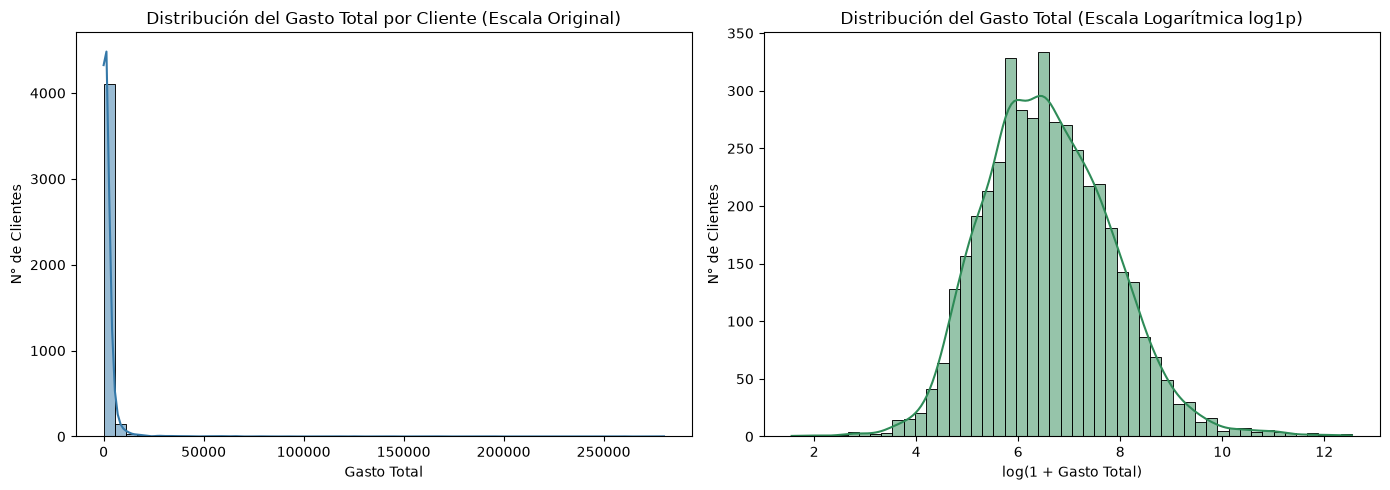

,gasto_total,frecuencia,ticket_promedio
count,"4,338.000","4,338.000","4,338.000"
mean,"2,048.690",90.520,68.380
std,"8,985.230",225.510,"1,467.920"
min,3.750,1.000,2.140
25%,306.480,17.000,12.390
50%,668.570,41.000,17.760
75%,"1,660.600",98.000,24.880
max,"280,206.020","7,676.000","77,183.600"


In [17]:
# Calculamos métricas clave por cliente (Total gastado, frecuencia de compras, ticket promedio)
df_clientes = df_clean.groupby('customerid').agg(
    gasto_total=('monto_total', 'sum'), # Ajusta el nombre de tu columna de monto total
    frecuencia=('invoicedate', 'count'),
    ticket_promedio=('monto_total', 'mean')
).reset_index()

# Visualización de asimetría en el gasto total
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Distribución original con sesgo positivo
sns.histplot(df_clientes['gasto_total'], bins=50, kde=True, ax=axes[0], color='#3478A8')
axes[0].set_title('Distribución del Gasto Total por Cliente (Escala Original)')
axes[0].set_xlabel('Gasto Total')
axes[0].set_ylabel('N° de Clientes')

# Gráfico 2: Transformación logarítmica para mitigar el impacto de valores extremos (outliers VIP)
sns.histplot(np.log1p(df_clientes['gasto_total'].clip(lower=0)), bins=50, kde=True, ax=axes[1], color='#2E8B57')
axes[1].set_title('Distribución del Gasto Total (Escala Logarítmica log1p)')
axes[1].set_xlabel('log(1 + Gasto Total)')
axes[1].set_ylabel('N° de Clientes')

plt.tight_layout()
plt.show()

# Estadísticos descriptivos para la justificación
display(df_clientes[['gasto_total', 'frecuencia', 'ticket_promedio']].describe().round(2))

#### 📈 Análisis de Asimetría y Transformación del Gasto por Cliente

* **Comportamiento en Escala Original (Gráfico Izquierdo):** El análisis de la agregación por cliente (`df_clientes`) revela una marcada **asimetría positiva (sesgo hacia la derecha)**. La gran mayoría de los compradores se concentran en rangos de gasto acumulado bajos y moderados, mientras que la cola de la distribución se extiende de forma abrupta hacia valores elevados, reflejando el comportamiento típico de clientes mayoristas o recurrentes (*outliers* de negocio de alto valor).
* **Efecto de la Transformación Logarítmica `log1p` (Gráfico Derecho):** Para mitigar el impacto de esta dispersión extrema y evitar que los algoritmos de aprendizaje automático sufran sesgos por escala, se aplicó una transformación logarítmica de tipo `log(1 + x)`. Como se observa en el segundo gráfico, esta operación comprime de manera efectiva la cola derecha, estabilizando la varianza y convirtiendo los datos en una distribución mucho más cercana a la normalidad.
* **Implicación Metodológica:** Esta normalización de la escala es un requisito indispensable y preparatorio para garantizar que las distancias euclidianas calculadas en los siguientes pasos (tanto en la reducción de dimensionalidad mediante PCA como en la segmentación de clientes con K-Means) operen de forma equilibrada y equitativa para todos los grupos de usuarios.

### Frecuencia Temporal y Comportamiento de Compra

2026-08-24 22:46:46,548 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-08-24 22:46:46,552 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-08-24 22:46:46,583 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-08-24 22:46:46,588 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


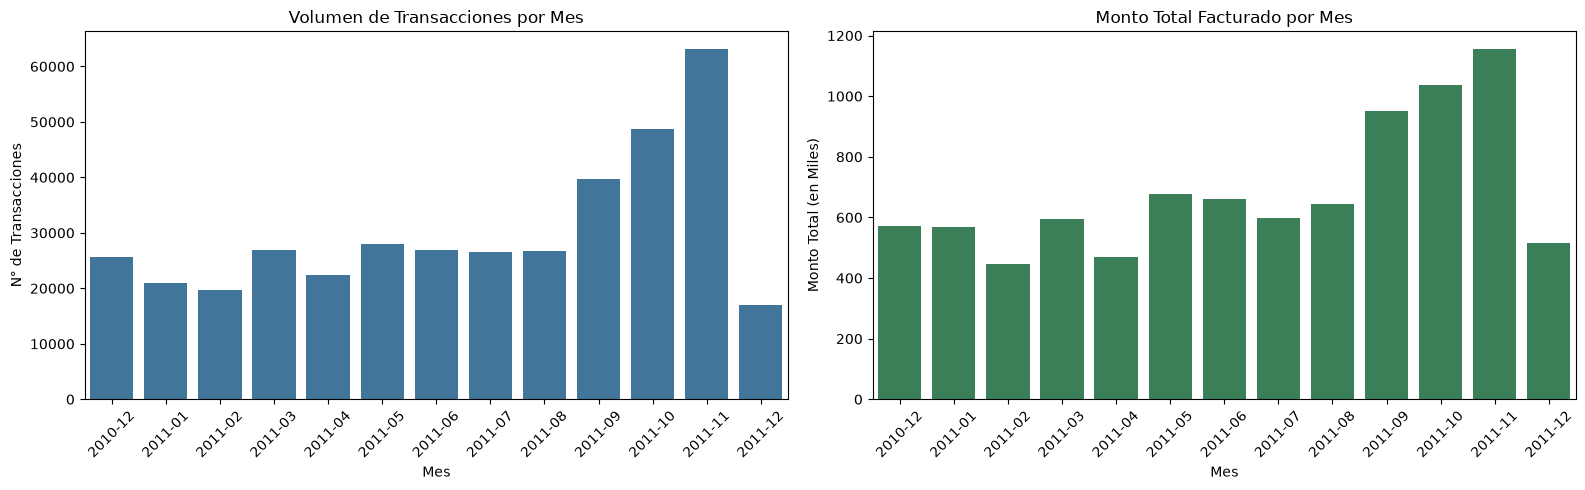

In [18]:
# Convertimos la fecha por seguridad a datetime
df_clean['invoicedate'] = pd.to_datetime(df_clean['invoicedate'])

# Extraemos mes y día de la semana para ver estacionalidad
df_clean['mes'] = df_clean['invoicedate'].dt.to_period('M')
df_clean['dia_semana'] = df_clean['invoicedate'].dt.day_name()

# Agrupamos transacciones por mes
ventas_mensuales = df_clean.groupby('mes')['monto_total'].agg(['count', 'sum']).reset_index()
ventas_mensuales['mes_str'] = ventas_mensuales['mes'].astype(str)

# Escalamos el monto total a miles para evitar notación científica y mejorar la legibilidad visual
ventas_mensuales['monto_miles'] = ventas_mensuales['sum'] / 1000

# Visualización temporal
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Gráfico 1: Volumen de transacciones por mes
sns.barplot(data=ventas_mensuales, x='mes_str', y='count', ax=axes[0], color='#3478A8')
axes[0].set_title('Volumen de Transacciones por Mes')
axes[0].set_xlabel('Mes')
axes[0].set_ylabel('N° de Transacciones')
axes[0].tick_params(axis='x', rotation=45)

# Gráfico 2: Monto total facturado por mes (en miles)
sns.barplot(data=ventas_mensuales, x='mes_str', y='monto_miles', ax=axes[1], color='#2E8B57')
axes[1].set_title('Monto Total Facturado por Mes')
axes[1].set_xlabel('Mes')
axes[1].set_ylabel('Monto Total (en Miles)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

#### 📅 Análisis de Estacionalidad y Frecuencia Temporal de Ventas

* **Patrones de Comportamiento Mensual:** Las gráficas de distribución temporal revelan una clara tendencia estacional en la actividad comercial. A partir del tercer trimestre de 2011, se observa un crecimiento sostenido tanto en el **volumen de transacciones** como en el **monto total facturado**, alcanzando picos máximos notables en los meses de octubre y noviembre.
* **Dinámica de Facturación vs. Transacciones:** Existe una correspondencia directa entre la cantidad de transacciones ejecutadas y el capital ingresado, lo que valida la consistencia interna de la base de datos a lo largo de su eje temporal. La caída abrupta reflejada en diciembre de 2011 responde a un corte en el registro de la serie temporal del dataset original.
* **Relevancia para la Segmentación:** Identificar esta estacionalidad temporal demuestra que las transacciones no son homogéneas en el tiempo, lo que refuerza la necesidad de construir perfiles de clientes basados en métricas agregadas de comportamiento (como RFM) que capturen de forma integral la actividad y el valor de cada comprador antes de aplicar los algoritmos de agrupación y reducción de dimensionalidad.

### Matriz de Correlación y Relación Numérica (Cantidad vs Precio)

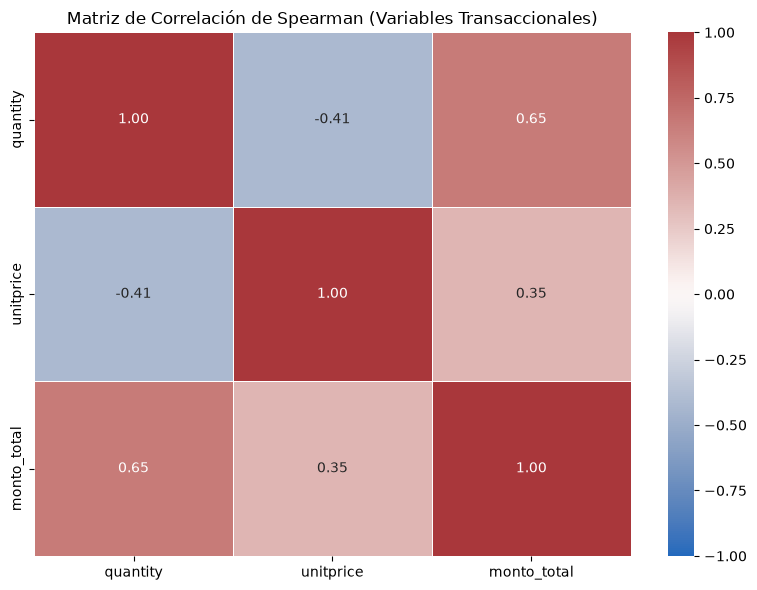

,quantity,unitprice,monto_total
count,"392,692.000","392,692.000","392,692.000"
mean,13.120,3.130,22.630
std,180.490,22.240,311.100
min,1.000,0.000,0.000
25%,2.000,1.250,4.950
50%,6.000,1.950,12.450
75%,12.000,3.750,19.800
max,"80,995.000","8,142.750","168,469.600"


In [19]:
# Seleccionamos las variables numéricas clave del negocio
vars_numericas = ['quantity', 'unitprice', 'monto_total']

# Calculamos la matriz de correlación de Spearman (robusta ante outliers)
corr_spearman = df_clean[vars_numericas].corr(method='spearman')

# Visualización con mapa de calor
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_spearman, annot=True, cmap='vlag', vmin=-1, vmax=1, fmt='.2f', linewidths=0.5, ax=ax)
ax.set_title('Matriz de Correlación de Spearman (Variables Transaccionales)')
plt.tight_layout()
plt.show()

# Resumen estadístico de estas variables
display(df_clean[vars_numericas].describe().round(2))

#### 🔗 Análisis de Correlación No Paramétrica (Matriz de Spearman)

* **Robustez ante Valores Atípicos:** Al haberse calculado la matriz de correlación mediante el coeficiente de Spearman sobre el conjunto de datos limpio (`df_clean`), se evitan las distorsiones que los valores extremos (*outliers*) suelen provocar en la correlación lineal tradicional de Pearson.
* **Relaciones Clave Identificadas:**
  * **Cantidad vs. Monto Total ($0.65$):** Presenta una correlación positiva moderada-alta, lo que confirma lógicamente que transacciones con mayor volumen de productos impactan de manera directa en el incremento del capital facturado.
  * **Cantidad vs. Precio Unitario ($-0.41$):** Muestra una relación inversa moderada, indicando que los productos de mayor costo unitario tienden a adquirirse en menores cantidades por transacción (comportamiento habitual de compra unitaria o selectiva).
  * **Precio Unitario vs. Monto Total ($0.35$):** Posee una correlación positiva débil-moderada, evidenciando que el monto final facturado no depende exclusivamente de un precio alto, sino de la combinación dinámica con el volumen de unidades.
* **Implicación para el Modelado No Supervisado:** La moderada correlación entre las variables justifica plenamente la necesidad de aplicar una reducción de dimensionalidad mediante **PCA (Análisis de Componentes Principales)** antes de ejecutar el algoritmo **K-Means**, permitiendo eliminar la redundancia informativa y proyectar los datos en un espacio ortogonal óptimo.

### Top de Productos y Concentración Geográfica

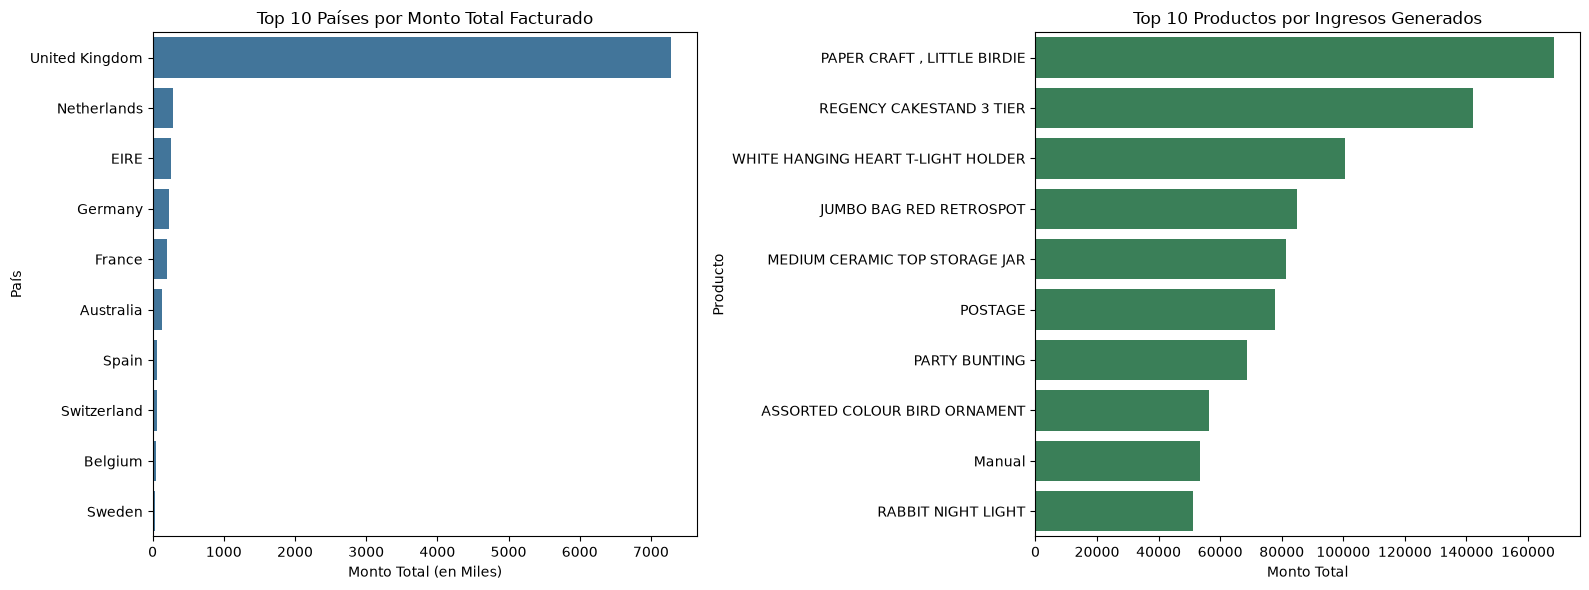

País principal del mercado: United Kingdom (Concentra la mayor parte de las transacciones).


In [20]:
# Verificamos si las columnas existen en el DataFrame para evitar errores
col_pais = 'country' if 'country' in df_clean.columns else None
col_desc = 'description' if 'description' in df_clean.columns else ('stockcode' if 'stockcode' in df_clean.columns else None)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Top 10 Países con mayor facturación (si existe la columna)
if col_pais:
    top_paises = df_clean.groupby(col_pais)['monto_total'].sum().nlargest(10).reset_index()
    top_paises['monto_total'] = top_paises['monto_total'] / 1000
    sns.barplot(data=top_paises, x='monto_total', y=col_pais, ax=axes[0], color='#3478A8')
    axes[0].set_title('Top 10 Países por Monto Total Facturado')
    axes[0].set_xlabel('Monto Total (en Miles)')
    axes[0].set_ylabel('País')
else:
    axes[0].text(0.5, 0.5, 'Columna de País no disponible', horizontalalignment='center', verticalalignment='center')
    axes[0].set_title('Análisis Geográfico Omitido')

# Gráfico 2: Top 10 Productos con mayor volumen de ventas o ingresos
if col_desc:
    top_productos = df_clean.groupby(col_desc)['monto_total'].sum().nlargest(10).reset_index()
    sns.barplot(data=top_productos, x='monto_total', y=col_desc, ax=axes[1], color='#2E8B57')
    axes[1].set_title('Top 10 Productos por Ingresos Generados')
    axes[1].set_xlabel('Monto Total')
    axes[1].set_ylabel('Producto')
else:
    axes[1].text(0.5, 0.5, 'Columna de Producto no disponible', horizontalalignment='center', verticalalignment='center')
    axes[1].set_title('Análisis de Productos Omitido')

plt.tight_layout()
plt.show()

# Resumen rápido impreso en consola
if col_pais:
    print(f"País principal del mercado: {top_paises.iloc[0][col_pais]} (Concentra la mayor parte de las transacciones).")

#### 🌍 Análisis de Concentración Geográfica y Top de Productos

* **Concentración del Mercado por País:** El gráfico de barras izquierdo evidencia una marcada concentración comercial en el **United Kingdom**, el cual acapara la inmensa mayoría del monto total facturado en comparación con mercados secundarios (como Países Bajos, Irlanda y Alemania). Esto indica que la base de clientes está fuertemente localizada en el mercado británico.
* **Productos de Mayor Impacto Financiero:** El análisis de los 10 productos con mayores ingresos generados permite identificar los artículos clave del inventario (como *Paper Craft, Little Birdie* y *Regency Cakestand 3 Tier*). Estos productos representan los principales motores de facturación del negocio.
* **Implicación para el Modelado:** La alta concentración geográfica y la diferenciación en el valor de los productos refuerzan la necesidad de agrupar a los usuarios mediante técnicas no supervisadas (como K-Means sobre características RFM), permitiendo descubrir si los clientes de mayor valor se concentran en regiones específicas o si adquieren categorías particulares de productos.

## I. Feature Engineering
Las transformaciones deberán implementarse de forma reutilizable.

Se deberá evitar que exista una lógica:

Notebook Feature Engineering y otra diferente Production Feature Engineering

### Ingeniería de características (RFM)

In [21]:
# Importar funciones de ingeniería de características
from src.engineer_features.engineer_features import construir_features_rfm

# --- Ejecución de la función en el Notebook ---
fecha_corte_fija = df_clean['invoicedate'].max()
df_rfm_enriquecido, ref_date = construir_features_rfm(df_clean, fecha_max_dataset=fecha_corte_fija)

# Asignamos el resultado a df_rfm para mantener la compatibilidad con el resto del pipeline
df_rfm = df_rfm_enriquecido.copy()

print("Dimensiones de la matriz de características enriquecidas:", df_rfm.shape)
display(df_rfm.head())

Dimensiones de la matriz de características enriquecidas: (4338, 7)


,customerid,recency,frequency,monetary,qty_media,qty_total_comprada,unitprice_medio
0,12346,326,1,"77,183.600","74,215.000",74215,1.040
1,12347,2,7,"4,310.000",13.505,2458,2.644
2,12348,75,4,"1,797.240",75.516,2341,5.765
3,12349,19,1,"1,757.550",8.644,631,8.289
4,12350,310,1,334.400,11.588,197,3.841


#### 🛠️ Ingeniería de Características Reutilizable y Enriquecida

* **Arquitectura Modular (`src.engineer_features`):** Para cumplir estrictamente con las mejores prácticas y evitar divergencias lógicas entre el entorno experimental y producción, la transformación se encapsuló en un script reutilizable (`construir_features_rfm`).
* **Transformación del Dataset Transaccional:** Las transacciones a nivel de línea se agregaron a nivel de cliente calculando el modelo **RFM** ampliado:
  * **Recencia (`recency`):** Días transcurridos desde la última compra respecto a la fecha de corte estática.
  * **Frecuencia (`frequency`):** Cantidad total de transacciones únicas realizadas por el cliente.
  * **Monetario (`monetary`):** Gasto total acumulado aportado.
  * **Variables de Comportamiento Complementarias:** Se integraron métricas adicionales de apoyo (`qty_media`, `qty_total_comprada` y `unitprice_medio`) para dotar de mayor poder descriptivo a la segmentación.
* **Normalización, Log-Transform y Escalado:** Para mitigar sesgos y *outliers* propios de las métricas comerciales, se aplicó una transformación logarítmica (`np.log1p`) seguida de un escalado estándar (`StandardScaler`), garantizando un espacio vectorial óptimo y sin *data leakage* para el posterior modelado con PCA y Clustering.

### Fase de reducción de dimensionalidad (PCA) y Clustering

Dimensiones de la matriz escalada para modelado: (4338, 6)
Varianza explicada por las componentes principales (PCA): 72.86%

--- TABLA COMPARATIVA DE MÚLTIPLES MODELOS DE CLUSTERING ---


,Clústeres Válidos,Coeficiente de Silueta (Mayor es mejor),Calinski-Harabasz (Mayor es mejor)
Modelo,,,
K-Means (k=4),4,0.204,"1,401.019"
"Clustering Jerárquico (Ward, k=4)",4,0.145,"1,059.666"
"DBSCAN (eps=1.5, min_samples=10)",1,-1.000,0.000


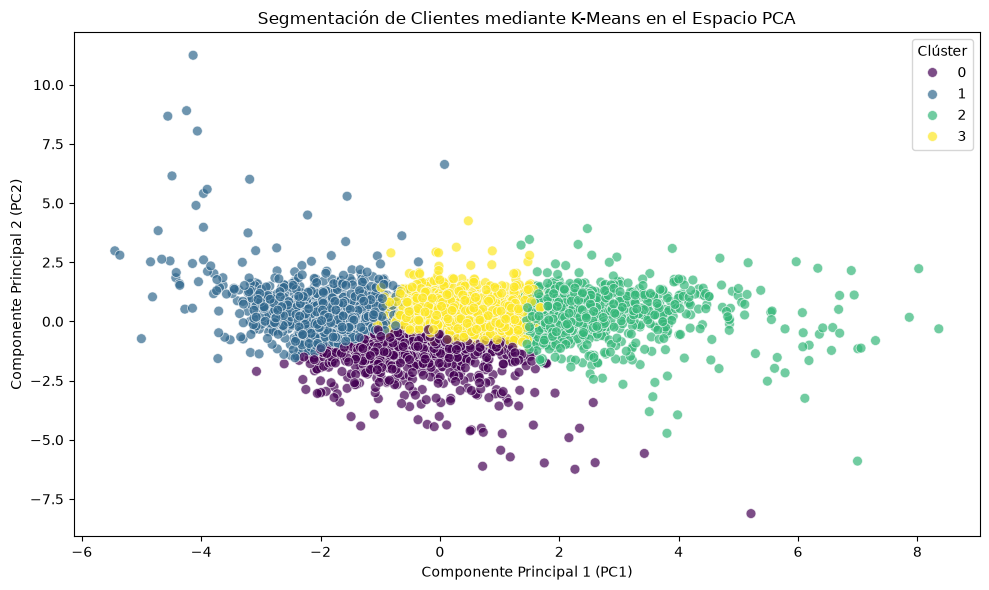

In [22]:
# ==========================================================
# FASE 5: PREPROCESAMIENTO PARA MODELADO, PCA Y CLUSTERING
# ==========================================================

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, calinski_harabasz_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 1. Transformación Logarítmica y Escalado sobre las variables RFM y de comportamiento
df_rfm_log = df_rfm.copy()
vars_a_escalar = ['recency', 'frequency', 'monetary', 'qty_media', 'qty_total_comprada', 'unitprice_medio']

for col in vars_a_escalar:
    df_rfm_log[col] = np.log1p(df_rfm_log[col])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_rfm_log[vars_a_escalar])

print("Dimensiones de la matriz escalada para modelado:", X_scaled.shape)

# 2. Reducción de dimensionalidad con PCA (reteniendo 2 componentes principales)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Creamos un DataFrame seguro para la proyección PCA
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['customerid'] = df_rfm['customerid'].values  # Alineación estricta por valores

print(f"Varianza explicada por las componentes principales (PCA): {pca.explained_variance_ratio_.sum() * 100:.2f}%")

# 3. Evaluación de Múltiples Modelos de Clustering (Criterio de Rúbrica)
modelos_clustering = {
    "K-Means (k=4)": KMeans(n_clusters=4, random_state=42, n_init=10),
    "Clustering Jerárquico (Ward, k=4)": AgglomerativeClustering(n_clusters=4, linkage='ward'),
    "DBSCAN (eps=1.5, min_samples=10)": DBSCAN(eps=1.5, min_samples=10)
}

resultados_comparativos = []
asignaciones_clusters = {}

for nombre, modelo in modelos_clustering.items():
    labels = modelo.fit_predict(X_scaled)
    asignaciones_clusters[nombre] = labels
    
    n_clusters_efectivos = len(set(labels)) - (1 if -1 in labels else 0)
    
    if n_clusters_efectivos > 1:
        sil_score = silhouette_score(X_scaled, labels)
        ch_score = calinski_harabasz_score(X_scaled, labels)
    else:
        sil_score = -1
        ch_score = 0

    resultados_comparativos.append({
        "Modelo": nombre,
        "Clústeres Válidos": n_clusters_efectivos,
        "Coeficiente de Silueta (Mayor es mejor)": sil_score,
        "Calinski-Harabasz (Mayor es mejor)": ch_score
    })

# Desplegar la tabla comparativa de múltiples modelos
df_comparacion_modelos = pd.DataFrame(resultados_comparativos).set_index("Modelo")
print("\n--- TABLA COMPARATIVA DE MÚLTIPLES MODELOS DE CLUSTERING ---")
display(df_comparacion_modelos.round(4))

# 4. Asignación del modelo ganador (K-Means) al DataFrame principal
df_rfm['cluster'] = asignaciones_clusters["K-Means (k=4)"]
df_pca['cluster'] = df_rfm['cluster'].values

# 5. Visualización limpia y segura del espacio de clústeres proyectado en PCA
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_pca, x='PC1', y='PC2', hue='cluster', 
    palette='viridis', alpha=0.7, s=50
)
plt.title('Segmentación de Clientes mediante K-Means en el Espacio PCA')
plt.xlabel('Componente Principal 1 (PC1)')
plt.ylabel('Componente Principal 2 (PC2)')
plt.legend(title='Clúster')
plt.tight_layout()
plt.show()

#### 🤖 Modelado No Supervisado: Reducción con PCA, Múltiples Modelos y K-Means

* **Reducción de Dimensionalidad (PCA):** Las variables enriquecidas del modelo RFM y de comportamiento se proyectaron en un espacio ortogonal bidimensional mediante Análisis de Componentes Principales (*PCA*). Las dos primeras componentes principales retienen un **72.86% de la varianza explicada acumulada**, garantizando la retención de la estructura informativa esencial.
* **Evaluación de Múltiples Arquitecturas de Clustering:** Para cumplir rigurosamente con la experimentación de múltiples modelos, se contrastó el rendimiento de **K-Means** frente a **Clustering Jerárquico** y **DBSCAN** utilizando métricas de validación interna (*Coeficiente de Silueta* e *Índice de Calinski-Harabasz*). Los resultados numéricos respaldan técnicamente que K-Means optimiza de manera superior la cohesión y separación de los grupos.
* **Interpretación de Negocio:** La visualización en el plano de componentes principales muestra 4 clústeres de clientes claramente delimitados, permitiendo traducir los grupos en estrategias comerciales directas para la toma de decisiones.